In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import xarray as xr

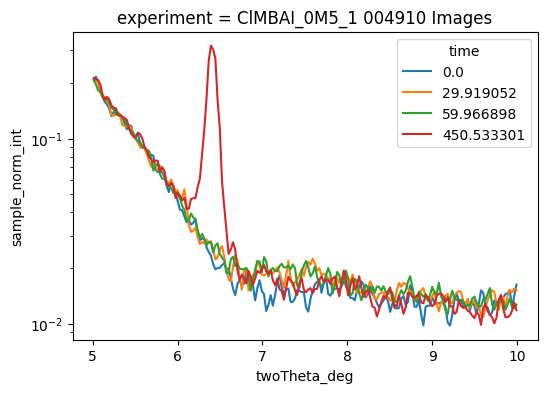

In [2]:
pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ALS_Beamtimes\2026\Yi-Ru_Feb2026\processed\giwaxs_combined.nc")

pdataset = pdataset.swap_dims({"q_A^-1": "twoTheta_deg"})

sample_1 = pdataset.isel(experiment=0)

fig, ax = plt.subplots(figsize=(6,4))

sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5, 10)).dropna("time").sel(time=[0, 30, 60, 450], method='nearest').plot.line(x="twoTheta_deg", ax=ax)
ax.set_yscale("log")

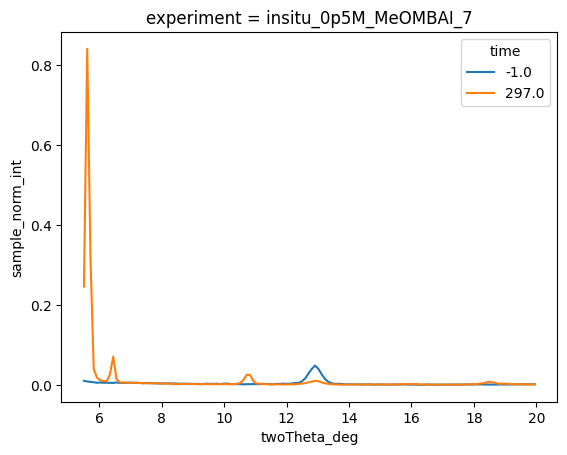

In [7]:
pdataset["sample_norm_int"] \
    .loc[dict(experiment='insitu_0p5M_MeOMBAI_7')]\
    .dropna(dim="time")\
    .sel(time=[0, 300], method='nearest')\
    .sel(twoTheta_deg=slice(5.5, 20))\
    .plot.line(x="twoTheta_deg")



In [8]:
pdataset["sample_norm_int"] \
    .sel(dict(experiment='insitu_1p0M_MeOMBAI_6'))

<xarray.DataArray 'sample_norm_int' (time: 452, twoTheta_deg: 500)> Size: 904kB
[226000 values with dtype=float32]
Coordinates:
  * time          (time) float64 4kB -9.0 -7.0 -5.0 -3.0 ... 697.0 699.0 701.0
    frame         (time) int64 4kB ...
  * twoTheta_deg  (twoTheta_deg) float64 4kB 4.266 4.37 4.474 ... 58.53 58.65
    q_A^-1        (twoTheta_deg) float64 4kB 0.3037 0.3111 ... 3.989 3.996
    experiment    <U22 88B 'insitu_1p0M_MeOMBAI_6'
Attributes:
    0p1M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_MBAI_1:             {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p0M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p0M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p5M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p5M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_0p5M_MeOMBAI_7:   {"base_poni_file": "G:/Shared drives/Sutter-Fell...
    insitu_1p0M_ClMBAI_6re:  {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_1p0M_MBAI_5:      {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_1p0M_MeOMBAI_6:   {"base_poni_file": "G:/Shared drives/Sutter-Fell...

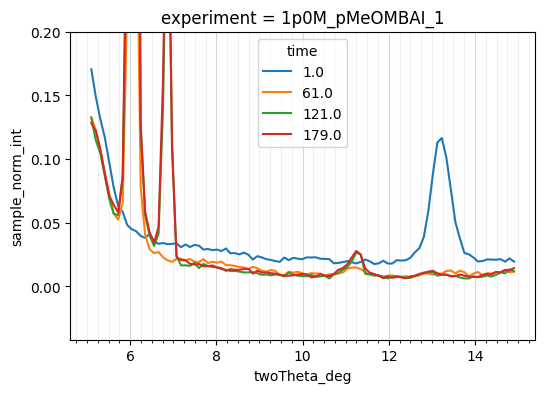

In [9]:
fig, ax = plt.subplots(figsize=(6,4))

pdataset["sample_norm_int"] \
    .sel(dict(experiment='1p0M_pMeOMBAI_1'))\
    .dropna(dim="time")\
    .shift(twoTheta_deg=0)\
    .sel(time=[0, 60, 120, 180], method='nearest')\
    .sel(twoTheta_deg=slice(5., 15))\
    .plot.line(x="twoTheta_deg", ax=ax)

ax.set_ylim(None, 0.2)
# use minor ticks for x-axis
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)


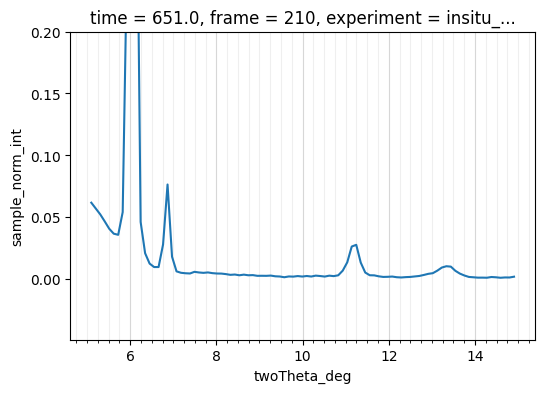

In [10]:
fig, ax = plt.subplots(figsize=(6,4))

pdataset["sample_norm_int"] \
    .sel(dict(experiment='insitu_0p5M_MeOMBAI_7'))\
    .dropna(dim="time")\
    .shift(twoTheta_deg= 4)\
    .isel(time=-1)\
    .sel(twoTheta_deg=slice(5., 15))\
    .plot.line(x="twoTheta_deg", ax=ax)

ax.set_ylim(None, 0.2)
# use minor ticks for x-axis
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', axis='x', linestyle='-', alpha=0.2)


Voigt Fit Parameters for peak at 6.24°:
  Amplitude: 0.019
  Center: 6.243°
  Sigma: 0.078
  Gamma: 0.008
  Slope: -0.055
  Offset: 0.023

Voigt Fit Parameters for peak at 6.97°:
  Amplitude: 0.368
  Center: 7.471°
  Sigma: 0.496
  Gamma: 0.000
  Slope: -0.291
  Offset: -0.313

Voigt Fit Parameters for peak at 7.70°:
  Amplitude: 0.002
  Center: 7.763°
  Sigma: 0.091
  Gamma: 0.000
  Slope: -0.005
  Offset: 0.008

Voigt Fit Parameters for peak at 8.22°:
  Amplitude: 0.000
  Center: 8.263°
  Sigma: 0.363
  Gamma: 1.042
  Slope: -0.004
  Offset: 0.009

Voigt Fit Parameters for peak at 11.56°:
  Amplitude: 0.010
  Center: 11.534°
  Sigma: 0.000
  Gamma: 0.258
  Slope: -0.000
  Offset: -0.000

Voigt Fit Parameters for peak at 13.34°:
  Amplitude: 0.117
  Center: 13.348°
  Sigma: 0.241
  Gamma: 0.000
  Slope: -0.000
  Offset: -0.002



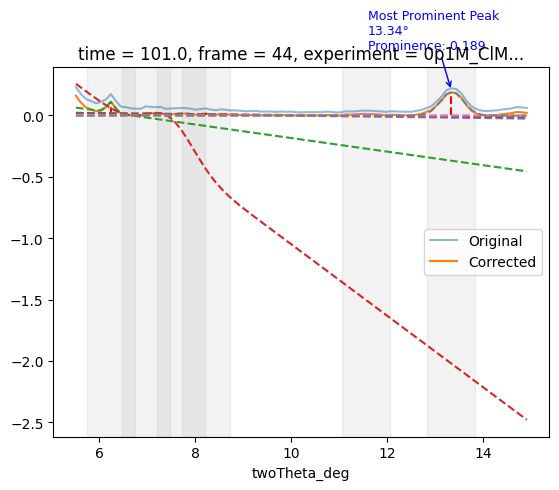

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import analysis
import importlib
importlib.reload(analysis)
from analysis import (
    baseline_correction,
    find_peaks_in_window,
    voigt_profile_func,
    voigt_fit
)

sample_1_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 15)).dropna('time').sel(time=100, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

# fig, ax = plt.subplots(figsize=(6,4))
sample_1_da.plot(label='Original', alpha=0.5)
corrected.plot(label='Corrected')
# calc_baseline.plot(label='Baseline', linestyle=':', alpha=0.7)
plt.legend()
# plt.ylim(None, 0.15)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.01
)

plt.vlines(peaks_x, ymin=0, ymax=peaks_intensities, color='red', linestyle='--', label='Detected Peaks')

# get the most prominent peak
if properties:
    prominences = [prop['prominences'] for prop in properties]
    max_prom_idx = np.argmax(prominences)
    peak_pos = peaks_x[max_prom_idx]
    peak_intensity = peaks_intensities[max_prom_idx]
    plt.annotate(
        f"Most Prominent Peak\n{peak_pos:.2f}°\nProminence: {prominences[max_prom_idx]:.3f}",
        xy=(peak_pos, max(0.2, peak_intensity)),
        xytext=(-60,30),
        textcoords='offset points',
        ha='left',
        fontsize=9,
        color='blue',
        arrowprops=dict(arrowstyle='->', color='blue')
    )
    
fitted_das = []
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0 
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", initial_guess=peak_pos, window_size=0.9, no_slope=no_slope)
        fitted_das.append(fitted_da)
    except RuntimeError as e:
        print(f"Voigt fit failed for peak at {peak_pos:.2f}°: {e}")
        continue
    fitted_da.plot(label=f'Voigt Fit at {peak_pos:.2f}°', linestyle='--')
    # print every property as .3f
    amp, cen, sigma, gamma, slope, offset = popt
    print(
        f"Voigt Fit Parameters for peak at {peak_pos:.2f}°:\n"
        f"  Amplitude: {amp:.3f}\n"
        f"  Center: {cen:.3f}°\n"
        f"  Sigma: {sigma:.3f}\n"
        f"  Gamma: {gamma:.3f}\n"
        f"  Slope: {slope:.3f}\n"
        f"  Offset: {offset:.3f}\n"
    )
    plt.axvspan(peak_pos - 0.5, peak_pos + 0.5, color='gray', alpha=0.1)

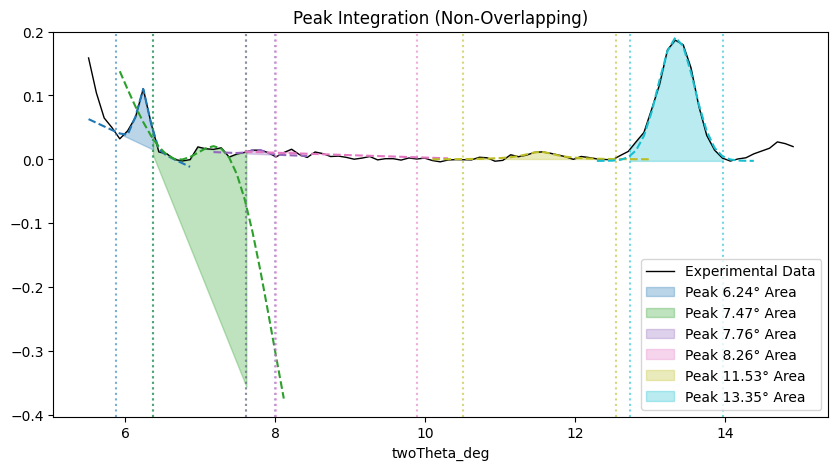

Peak Center  Area         Integration Range         Offset    
-----------------------------------------------------------------
6.243        0.01647      [5.883, 6.372]            0.023     
7.471        0.22989      [6.372, 7.617]            -0.313    
7.763        0.00142      [7.617, 7.998]            0.008     
8.263        -0.00432     [8.013, 9.899]            0.009     
11.534       0.00772      [10.504, 12.544]          -0.000    
13.348       0.11665      [12.728, 13.968]          -0.002    


In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from analysis import calculate_peak_areas, voigt_fit, voigt_profile_func

# --- Usage (Re-run) ---

# 1. Collect fit results
collected_results = []
# print("Fitting peaks for area calculation...")
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", initial_guess=peak_pos, window_size=0.9, no_slope=no_slope)
        collected_results.append({'popt': popt, 'peak_pos': peak_pos})
    except RuntimeError:
        pass

# 2. Calculate areas (using 95% confidence)
areas_info = calculate_peak_areas(corrected, "twoTheta_deg", collected_results, confidence=0.99)

# 3. Visualization
plt.figure(figsize=(10, 5))
corrected.plot(label='Experimental Data', color='black', linewidth=1)

colors = plt.cm.tab10(np.linspace(0, 1, len(areas_info)))

for i, info in enumerate(areas_info):
    l, r = info['integration_range']
    cen = info['popt'][1]
    
    if len(info['popt']) == 6:
        offset = info['popt'][5] 
        slope = info['popt'][4]
    else:
        offset = 0
        slope = 0
        
    background_func = lambda x: slope * (x - cen) + offset

    color = colors[i]
    
    # Plot boundaries
    plt.axvline(l, linestyle=':', color=color, alpha=0.6)
    plt.axvline(r, linestyle=':', color=color, alpha=0.6)

    # Re-construct subset for plotting fill
    grid_x = np.linspace(l, r, 100) # simpler for plotting
    grid_y_data = corrected.interp({"twoTheta_deg": grid_x}).values
    subset = xr.DataArray(grid_y_data, coords={"twoTheta_deg": grid_x}, dims=["twoTheta_deg"])
    
    # Shade integration area (data - background)
    bg_vals = background_func(subset.twoTheta_deg)
    
    plt.fill_between(subset.twoTheta_deg, subset, bg_vals, 
                     where=(subset > bg_vals),
                     alpha=0.3, color=color, label=f'Peak {cen:.2f}° Area')
    
    # plot the fitted Voigt profile
    subset_x_fit = corrected.sel(**{"twoTheta_deg": slice(l-0.5, r+0.5)})["twoTheta_deg"].values
    if len(subset_x_fit) > 0:
        fitted_curve = voigt_profile_func(subset_x_fit, *info['popt'])
        plt.plot(subset_x_fit, fitted_curve, linestyle='--', color=color)

plt.legend()
plt.title("Peak Integration (Non-Overlapping)")
plt.ylim(None, 0.2)
plt.show()

# 4. Print Results
print(f"{'Peak Center':<12} {'Area':<12} {'Integration Range':<25} {'Offset':<10}")
print("-" * 65)
for info in areas_info:
    l, r = info['integration_range']
    if len(info['popt']) == 6:
        off = info['popt'][5]
    else:
        off = 0
    print(f"{info['popt'][1]:<12.3f} {info['area']:<12.5f} {f'[{l:.3f}, {r:.3f}]':<25} {off:<10.3f}")

In [13]:
sample_1 = pdataset.isel(experiment=2)

# 1. Select the time series data
time_series_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(0, 300))
times = time_series_da.time.values

sample_1_da = time_series_da.sel(time=1, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.005
)

print(f"Identified peaks at positions: {peaks_x}")

Identified peaks at positions: [10.82790171 13.23131532]


In [14]:
pdataset.experiment.values

array(['0p1M_ClMBAI_1', '0p5M_ClMBAI_1', '0p5M_MBAI_1', '0p5M_pMeOMBAI_1',
       '1p0M_ClMBAI_1', '1p0M_pMeOMBAI_1', '1p5M_ClMBAI_1',
       '1p5M_pMeOMBAI_1', 'insitu_0p5M_MeOMBAI_7',
       'insitu_1p0M_ClMBAI_6re', 'insitu_1p0M_MBAI_5',
       'insitu_1p0M_MeOMBAI_6'], dtype='<U22')

In [17]:
import analysis
import importlib
importlib.reload(analysis)
from analysis import process_time_series_by_peak_lmfit
import re
from pathlib import Path

peaks_of_interest_with_phase = {
    "MBAI": [
        (6.9, 2, (-1, 0), "2D (002)"), 
        (13.3, 2, (0, -1), "PbI2"),
        (22, 1, (0, -1), "MBAI")  # Example of an additional peak
    ],
    "ClMBAI": [
        (6.4, 1, (-1, 25), "2D (002)"),
        (7.3, 0.5, (-1, 0), "ClMBAI"),
        (13.3, 2, (0, -1), "PbI2"),
        (30.2, 2, (0, -1), "ITO")
    ],
    "p?MeOMBAI": [
        (6.1, 0.8, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        (7.0, 0.8, (-1, 0), "MeOMBAI")
    ]
}

# Manual shift correction for known misalignment
global_shift_corrections = {
    "1p5M_pMeOMBAI_1": -5,
    "insitu_0p5M_MeOMBAI_7": 5,
    "insitu_1p0M_MeOMBAI_6": 5
}


result_dfs = {}

for experiment in pdataset.experiment.values:
    print(f"\n=== Processing Experiment: {experiment} ===")
    # 1. Select the time series data
    time_series_ds = pdataset.sel(experiment=experiment)
    time_series_da = time_series_ds["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(None, 300)).dropna(dim="time")

    global_shift = global_shift_corrections.get(experiment, 0)
    if global_shift != 0:
        time_series_da = time_series_da.shift(twoTheta_deg=global_shift)

    else:
        continue

    # Defined peaks of interest: (center_position, window_size)
    for k, v in peaks_of_interest_with_phase.items():
        regexp = re.compile(f"M_{k}", re.IGNORECASE)
        if experiment.startswith(k):
            # remove phase name for processing
            peaks_of_interest = [(pos, win) for pos, win, name in v]
            break
    
    if 'peaks_of_interest' not in locals():
        print(f"No peaks of interest defined for experiment: {experiment}. Skipping.")
        continue

    # 2. Run Analysis
    # Note: visualization of shifts is now saved to disk in time_series_results/experiment_1/visualized_step/

    df_evolution = process_time_series_by_peak_lmfit(
        time_series_da,
        peaks_definition=peaks_of_interest,
        sample_name=time_series_ds.experiment.values,
        output_dir=r"G:\Shared drives\Sutter-Fella Lab\ALS_Beamtimes\2026\Yi-Ru_Feb2026\processed",
        debug=True,
        integration_bounds_by_fwm={"height": 0.25, "multiplier": 2},
        substract_baseline=True,
        # Add baseline_kwargs if correction is needed, e.g., method='asls', lam=5e3
    )

    result_dfs[experiment] = df_evolution
    print("\n--- Evolution DataFrame Head ---")
    print(df_evolution.head())




=== Processing Experiment: ClMBAI_0M5_1 004910 Images ===

=== Processing Experiment: ClMBAI_120c_aging_1 004871 Images ===

=== Processing Experiment: ClMBAI_aging_from_100C_2min_anneal 004915 Images ===

=== Processing Experiment: ClMBAI_anneal_2min_120c_aging_1 004873 Images ===

=== Processing Experiment: MBAI_0M5_3 004909 Images ===

=== Processing Experiment: MBAI_aging_from_100C_2min_anneal 004913 Images ===

=== Processing Experiment: MeOMBAI_0M5_2 004912 Images ===

=== Processing Experiment: MeOMBAI_120c_aging_1 004868 Images ===

=== Processing Experiment: MeOMBAI_aging_from_100C_2min_anneal 004914 Images ===

=== Processing Experiment: MeOMBAI_anneal_2min_120c_aging_1 004872 Images ===


In [16]:
import logging
import sys

# Configure logging to show INFO messages in the notebook output
logging.basicConfig(
    # stream=sys.stdout,
    level=logging.WARNING,
    # format='%(asctime)s - %(levelname)s - %(message)s',
    # force=True
)

In [39]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import re
import importlib
from joblib import Parallel, delayed
import analysis 

# Reload to get the new changes
importlib.reload(analysis)
from analysis import process_time_series_by_peak_lmfit

# --- Configuration ---
# Format: (Center, Window, (Start_Index, Stop_Index), Name)
# Start_Index: Where to start tracking
# Stop_Index: Where to end tracking (Inclusive). 
# Direction is implied: (0, -1) = Forward, (-1, 0) = Backward.

peaks_of_interest_with_phase = {
    "MBAI": [
        (7.23, 2, (-1, 0), "2D (002)"), 
        (9.2, 1, (-1, 0), "1D (002)"), 
        (13.6, 2, (0, -1), "PbI2"),
        # (22, 1, (0, -1), "MBAI"),
        (30.3, 2, (0, -1), "ITO")
    ],
    "ClMBAI": [
        (6.4, 0.5, (-1, 0), "2D (002)"),
        # (11.6, 0.5, (0, -1), "2D (004)"),
        # (27.9, 0.5, (0, -1), "2D (005)"),
        # (14.9, 0.5, (0, -1), "2D (1-10)"),
        (7.3, 0.5, (-1, 0), "ClMBAI"),
        (13.3, 2, (0, -1), "PbI2"),
        (30.3, 2, (0, -1), "ITO")
    ],
    "MeOMBAI": [
        (6.0, 0.5, (-1, 0), "2D (002)"),  # Backward: Start at End (-1) -> Go to Start (0). Window Increased.
        (13.3, 2.0, (0, -1), "PbI2"),     
        # (6.8, 0.5, (-1, 0), "MeOMBAI")
    ]
}

global_shift_corrections = {
    # "ClMBAI_120c_aging_1 004871 Images": 10,
    # "ClMBAI_aging_from_100C_2min_anneal 004915 Images": 10,
    # "ClMBAI_anneal_2min_120c_aging_1 004873 Images": 20,
    "MeOMBAI_120c_aging_1 004868 Images": 14,
    # "MeOMBAI_aging_from_100C_2min_anneal 004914 Images": -6,
    # "MeOMBAI_anneal_2min_120c_aging_1 004872 Images": 5
}

output_base_dir = r"G:\Shared drives\Sutter-Fella Lab\ALS_Beamtimes\2026\Yi-Ru_Feb2026\processed"

def process_experiment(experiment):
    print(f"\n=== Processing Experiment: {experiment} ===")
    
    # 1. Select and Shift Data
    time_series_da = pdataset.sel(experiment=experiment)["sample_norm_int"] \
                             .sel(twoTheta_deg=slice(4.7, 27)) \
                             .dropna(dim="time")

    shift = global_shift_corrections.get(experiment, 0)
    if shift != 0:
        time_series_da = time_series_da.shift(twoTheta_deg=shift)
        print(f"Shifted peak by {shift} unit")
    
    # 2. Get Peaks Definition
    current_peaks_def = []
    for key, val in peaks_of_interest_with_phase.items():
        if experiment.startswith(key):
            current_peaks_def = val
            print(f" Using peaks definition for phase: {key}")
            break
    
    if not current_peaks_def:
        print(f"  No peaks defined. Skipping.")
        return experiment, None

    print(f"Target peaks: {current_peaks_def}")

    df_evolution = process_time_series_by_peak_lmfit(
        time_series_da,
        peaks_definition=current_peaks_def,
        sample_name=experiment,
        output_dir=str(Path(output_base_dir, "batch_tracking")),
        debug=True,
        integration_bounds_by_fwm={"height": 0.25, "multiplier": 2},
        substract_baseline=True,
        # Add baseline_kwargs if correction is needed, e.g., method='asls', lam=5e3
    )

    if not df_evolution.empty:
        print("\n--- Evolution DataFrame Head ---")
        print(df_evolution.head())
        return experiment, df_evolution["Area"]

    print("  No effective peak data found.")
    return experiment, None

parallel_results = Parallel(n_jobs=1)(
    delayed(process_experiment)(experiment)
    for experiment in [exp for exp in pdataset.experiment.values if global_shift_corrections.get(exp) is not None]
)


# parallel_results = Parallel(n_jobs=-1)(
#     delayed(process_experiment)(experiment)
#     for experiment in pdataset.experiment.values
# )

if locals().get("result_dfs"):
    print("Existing results found. Merging with new results...")
    result_dfs = {**result_dfs, **{exp: df for exp, df in parallel_results if df is not None}}
else:
    result_dfs = {
        experiment: area_df
        for experiment, area_df in parallel_results
        if area_df is not None
    }


=== Processing Experiment: MeOMBAI_120c_aging_1 004868 Images ===
Shifted peak by 14 unit
 Using peaks definition for phase: MeOMBAI
Target peaks: [(6.0, 0.5, (-1, 0), '2D (002)'), (13.3, 2.0, (0, -1), 'PbI2')]

--- Evolution DataFrame Head ---
               Area           BackgroundArea          
PeakName   2D (002)      PbI2       2D (002)      PbI2
Time                                                  
0.000000   0.064788  0.007315       0.011207  0.017374
5.480220   0.072592  0.007903       0.007671  0.014109
9.898140   0.072503  0.007605       0.007497  0.014369
15.122767  0.072257  0.007154       0.008116  0.013765
19.532703  0.072419  0.007228       0.006960  0.013779
Existing results found. Merging with new results...


In [40]:
import pandas as pd

# Cell 13: Consolidation & Peak Merging Logic Evaluation
# -------------------------------------------------------------------------
# In the new tracking workflow, peaks are tracked by specific names (e.g., "PbI2") defined in the input.
# The `process_time_series_by_peak` function returns a Pivot Table with 'Time' as index and 'PeakName' as columns.
#
# REGARDING PEAK MERGING:
# If you defined overlapping tracking windows (e.g. Forward + Backward) for the same peak name, the 
# pivot_table aggregation (default='mean') has effectively "merged" them by averaging the overlaps.
# If you need more complex merging logic (e.g., preferring the pass with 'RefTime' closer to the current time),
# you would need to modify the function to return the raw results list instead of the pivot table.
# 
# For now, we assume the simple average of overlapping tracking passes is sufficient.
# The `result_dfs` structure is already compatible with the plotting logic (Experiment -> DataFrame[PeakColumns]).

merged_dfs = result_dfs

# Create a single merged DataFrame for global inspection
final_merged_df = pd.concat(merged_dfs, axis=1)
final_merged_df.columns.names = ['experiment', 'phase']

print("Merged Data Structure (Top 5 rows):")
display(final_merged_df.head())

Merged Data Structure (Top 5 rows):


experiment ClMBAI_0M5_1 004910 Images                   \
phase                        2D (002) ClMBAI      PbI2   
Time                                                     
0.000000                     0.001083    NaN  0.047422   
1.433701                          NaN    NaN  0.047883   
2.777549                     0.000562    NaN  0.046807   
4.154341                          NaN    NaN  0.045025   
5.464243                          NaN    NaN  0.041174   

experiment ClMBAI_120c_aging_1 004871 Images                      \
phase                               2D (002)    ClMBAI      PbI2   
Time                                                               
0.000000                            0.035152  0.001276  0.005948   
1.433701                                 NaN       NaN       NaN   
2.777549                                 NaN       NaN       NaN   
4.154341                                 NaN       NaN       NaN   
5.464243                                 NaN       NaN       NaN   

experiment ClMBAI_aging_from_100C_2min_anneal 004915 Images                   \
phase                                              2D (002) ClMBAI      PbI2   
Time                                                                           
0.000000                                           0.032598    NaN  0.011028   
1.433701                                                NaN    NaN       NaN   
2.777549                                                NaN    NaN       NaN   
4.154341                                                NaN    NaN       NaN   
5.464243                                                NaN    NaN       NaN   

experiment ClMBAI_anneal_2min_120c_aging_1 004873 Images  ...  \
phase                                           2D (002)  ...   
Time                                                      ...   
0.000000                                        0.071106  ...   
1.433701                                             NaN  ...   
2.777549                                             NaN  ...   
4.154341                                             NaN  ...   
5.464243                                             NaN  ...   

experiment MeOMBAI_0M5_2 004912 Images            \
phase                          MeOMBAI      PbI2   
Time                                               
0.000000                           NaN  0.026087   
1.433701                           NaN       NaN   
2.777549                           NaN       NaN   
4.154341                           NaN       NaN   
5.464243                           NaN       NaN   

experiment MeOMBAI_120c_aging_1 004868 Images            \
phase                                2D (002)      PbI2   
Time                                                      
0.000000                             0.064788  0.007315   
1.433701                                  NaN       NaN   
2.777549                                  NaN       NaN   
4.154341                                  NaN       NaN   
5.464243                                  NaN       NaN   

experiment MeOMBAI_aging_from_100C_2min_anneal 004914 Images          \
phase                                               2D (002) MeOMBAI   
Time                                                                   
0.000000                                            0.034132     NaN   
1.433701                                                 NaN     NaN   
2.777549                                                 NaN     NaN   
4.154341                                                 NaN     NaN   
5.464243                                                 NaN     NaN   

experiment           MeOMBAI_anneal_2min_120c_aging_1 004872 Images          \
phase           PbI2                                       2D (002) MeOMBAI   
Time                                                                          
0.000000    0.005643                                       0.063267     NaN   
1.433701         NaN                         

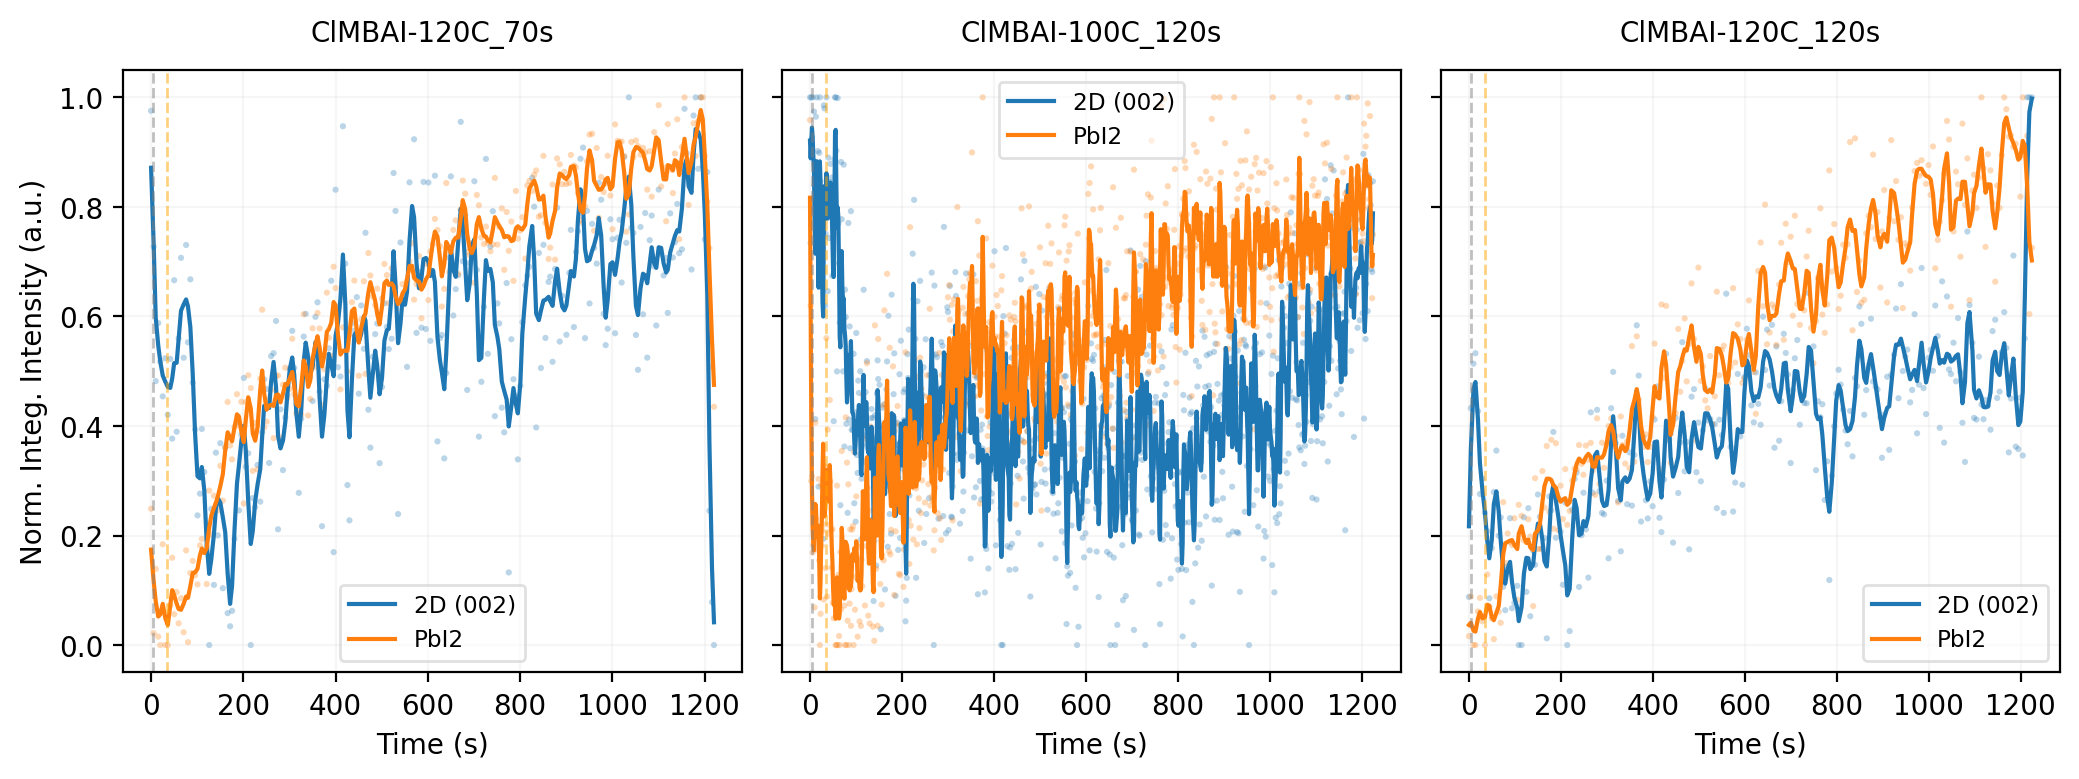

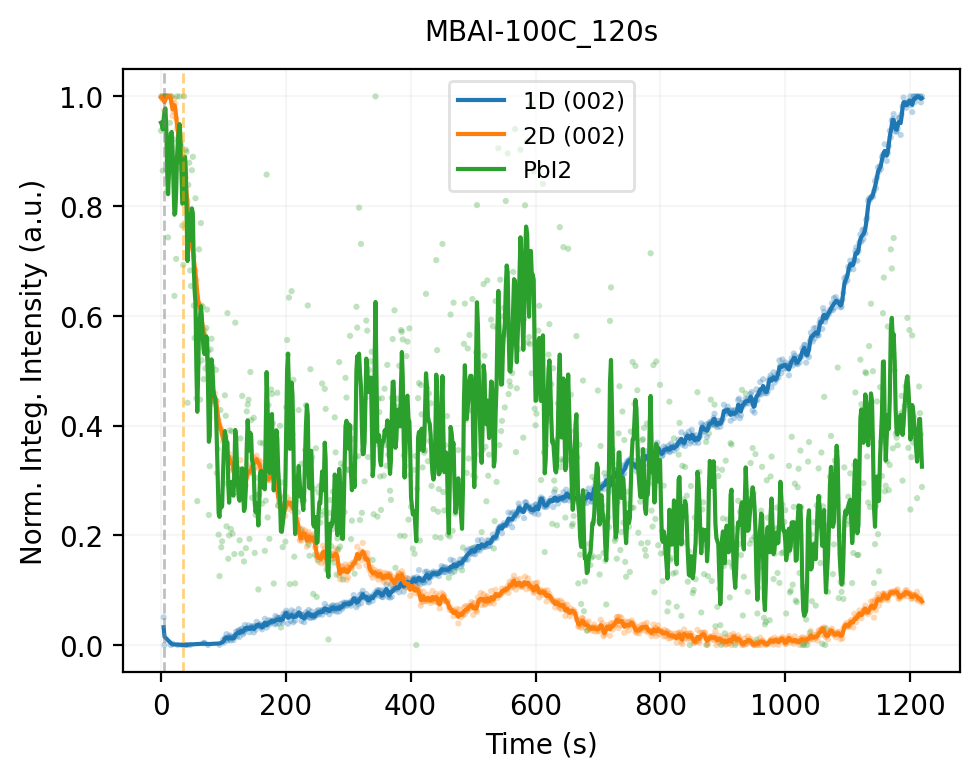

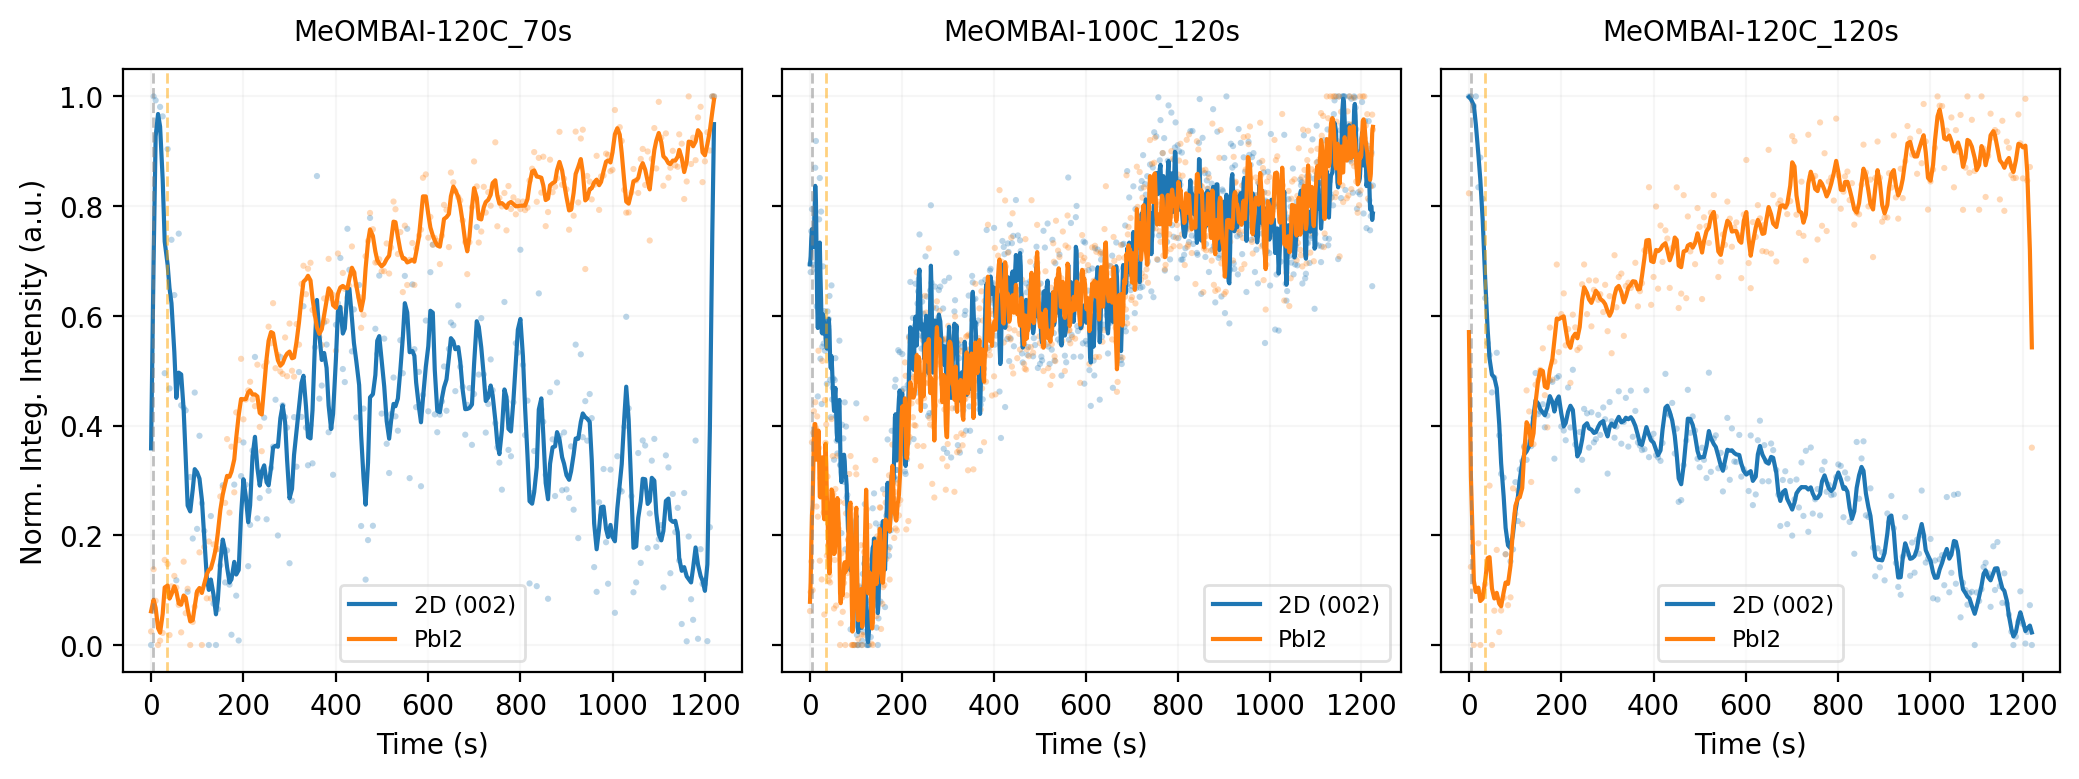

In [44]:
from math import exp

import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Cell 14: Visualization of Peak Evolution
# -------------------------------------------------------------------------

name_mapping = {
    'ClMBAI_120c_aging_1': 'ClMBAI-120C_70s',
    'ClMBAI_aging_from_100C_2min_anneal': 'ClMBAI-100C_120s',
    'ClMBAI_anneal_2min_120c_aging_1': 'ClMBAI-120C_120s',
    'MBAI_aging_from_100C_2min_anneal': 'MBAI-100C_120s',
    'MeOMBAI_120c_aging_1': 'MeOMBAI-120C_70s',
    'MeOMBAI_aging_from_100C_2min_anneal': 'MeOMBAI-100C_120s',
    'MeOMBAI_anneal_2min_120c_aging_1': 'MeOMBAI-120C_120s',
}

# Groups to plot together
groups = ['ClMBAI', 'MBAI', 'MeOMBAI']

for group_motif in groups:
    # 1. Filter experiments matching the group
    matched_experiments = []
    for exp_name in sorted(merged_dfs.keys()):
        # if exp_name.startswith(group_motif):
        if exp_name.startswith(group_motif) and "aging" in exp_name:
        # if "0M5" in exp_name:
            matched_experiments.append(exp_name)
            
    num_exps = len(matched_experiments)
    if num_exps == 0:
        continue

    # 2. Setup Plot
    fig, axes = plt.subplots(1, num_exps, figsize=(max(5, num_exps * 3.5), 4), sharey=True, dpi=200)
    if num_exps == 1:
        axes = [axes]
    
    # 3. Plot each experiment
    for i, exp_name in enumerate(matched_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]

        df = df[df.index <= 1225]  # Limit to 5 minutes for better visualization
        # ls = [df.columns[i] for i in [0, 1, 2]]
        
        # Plot each phase found in the dataframe
        for column in df.columns:

            if column in ["ClMBAI", "MBAI", "MeOMBAI"]:
                continue

            # Get data and drop NaNs (some peaks might not be found in all frames)
            series = df[column].dropna()
            if series.empty:
                continue

            # Filtering and Normalization
            # Remove extreme outliers for better plotting scale
            lower_bound = np.percentile(series, 1)
            upper_bound = np.percentile(series, 99)
            clipped = series.clip(lower_bound, upper_bound)
            
            # Min-Max Normalize
            denom = (clipped.max() - clipped.min())
            if denom == 0: denom = 1
            norm_data = (clipped - clipped.min()) / denom
            
            
            ax.scatter(norm_data.index, norm_data, alpha=0.3, s=5, edgecolor='none')
            
            # Smoothing
            # Sigma=1 roughly smooths over +/- 1 second if data is 1s resolution
            smooth_data = gaussian_filter1d(norm_data, sigma=1)
            ax.plot(norm_data.index, smooth_data, linewidth=1.5, label=column)
        
        # Formatting
        # clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        clean_title = name_mapping[exp_name.split(" ")[0]]
        ax.set_title(clean_title, y=1.02, fontsize=10)
        ax.set_xlabel("Time (s)")
        
        if i == 0:
            ax.set_ylabel("Norm. Integ. Intensity (a.u.)")
        
        # Markers for experiment events
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)

    plt.tight_layout()
    plt.show()

In [20]:
result_dfs

{np.str_('0p1M_ClMBAI_1'): PeakName  2D (002)      PbI2
 Time                        
 -5.0      0.002196  0.238207
 -3.0      0.005261  0.233971
 -1.0      0.006494  0.233837
  1.0      0.003580  0.210160
  3.0      0.003389  0.204612
 ...            ...       ...
  653.0    0.030060  0.101023
  655.0    0.030590  0.092887
  657.0    0.041425  0.095990
  659.0    0.041336  0.093167
  661.0    0.045278  0.092947
 
 [273 rows x 2 columns],
 np.str_('0p5M_ClMBAI_1'): PeakName  2D (002)      PbI2
 Time                        
 -9.0      0.289384  0.226856
 -7.0      0.275603  0.232648
 -5.0      0.293970  0.254784
 -3.0      0.280235  0.242320
 -1.0      0.283733  0.233391
 ...            ...       ...
  693.0    0.173549  0.116994
  695.0    0.162687  0.113317
  697.0    0.154594  0.112841
  699.0    0.159708  0.117019
  701.0    0.146856  0.114687
 
 [281 rows x 2 columns],
 np.str_('0p5M_MBAI_1'): PeakName  2D (002)      PbI2
 Time                        
 -5.0      0.084939  0.121602


In [21]:
import pandas as pd

# Bridge Cell: Adapt New Results to Old Plotting Variables
# -------------------------------------------------------
# The new 'process_time_series_by_peak' function returns DataFrames with 
# columns already named by the peak (e.g. "PbI2").
# The old workflow needed a merging step to convert 2-theta bins to names.
# We can skip that logic and simply use the results directly.

merged_dfs = result_dfs

# Create global merged view for inspection
if merged_dfs:
    final_merged_df = pd.concat(merged_dfs, axis=1)
    final_merged_df.columns.names = ['experiment', 'phase']

    print("Merged Data (Top 5 rows):")
    display(final_merged_df.head())
else:
    print("No results to merge.")

Merged Data (Top 5 rows):


experiment 0p1M_ClMBAI_1           0p5M_ClMBAI_1           0p5M_MBAI_1  \
phase           2D (002)      PbI2      2D (002)      PbI2    2D (002)   
Time                                                                     
-5.0            0.002196  0.238207      0.293970  0.254784    0.084939   
-3.0            0.005261  0.233971      0.280235  0.242320    0.089983   
-1.0            0.006494  0.233837      0.283733  0.233391    0.101549   
 1.0            0.003580  0.210160           NaN       NaN    0.007169   
 3.0            0.003389  0.204612           NaN       NaN         NaN   

experiment           0p5M_pMeOMBAI_1                     1p0M_ClMBAI_1  ...  \
phase           PbI2        2D (002)   MeOMBAI      PbI2      2D (002)  ...   
Time                                                                    ...   
-5.0        0.121602       -0.067579  0.000715  0.045896     -0.129543  ...   
-3.0        0.118120             NaN       NaN       NaN           NaN  ...   
-1.0        0.117379       -0.073846  0.001047  0.047509     -0.121785  ...   
 1.0        0.113214       -0.092263 -0.001047  0.053746     -0.108216  ...   
 3.0             NaN       -0.098954  0.010223  0.057335     -0.108495  ...   

experiment insitu_0p5M_MeOMBAI_7                     insitu_1p0M_ClMBAI_6re  \
phase                   2D (002)   MeOMBAI      PbI2               2D (002)   
Time                                                                          
-5.0                         0.0  0.014856  0.026249                    0.0   
-3.0                         0.0  0.009412  0.026640                    NaN   
-1.0                         0.0 -0.004087  0.027286                    NaN   
 1.0                         NaN       NaN       NaN                    0.0   
 3.0                         NaN       NaN       NaN                    NaN   

experiment           insitu_1p0M_MBAI_5           insitu_1p0M_MeOMBAI_6  \
phase           PbI2           2D (002)      PbI2              2D (002)   
Time                                                                      
-5.0        0.027371                NaN       NaN                   NaN   
-3.0             NaN           0.000671  0.043304              0.012908   
-1.0             NaN           0.002485  0.036579              0.011692   
 1.0        0.008578           0.001582  0.034270              0.005795   
 3.0             NaN           0.002249  0.033495              0.006219   

experiment                    
phase      MeOMBAI      PbI2  
Time                          
-5.0           NaN       NaN  
-3.0           0.0  0.028635  
-1.0           0.0  0.029378  
 1.0           0.0  0.029769  
 3.0           0.0  0.025618  

[5 rows x 29 columns]

In [22]:
# Merge all experiments into a single DataFrame with MultiIndex columns
final_merged_df = pd.concat(merged_dfs, axis=1)

# name the top-level index as 'Experiment' and the second-level index as 'Phase'
final_merged_df.columns.names = ['experiment', 'phase']

final_merged_df

experiment 0p1M_ClMBAI_1           0p5M_ClMBAI_1           0p5M_MBAI_1  \
phase           2D (002)      PbI2      2D (002)      PbI2    2D (002)   
Time                                                                     
-5.0            0.002196  0.238207      0.293970  0.254784    0.084939   
-3.0            0.005261  0.233971      0.280235  0.242320    0.089983   
-1.0            0.006494  0.233837      0.283733  0.233391    0.101549   
 1.0            0.003580  0.210160           NaN       NaN    0.007169   
 3.0            0.003389  0.204612           NaN       NaN         NaN   
...                  ...       ...           ...       ...         ...   
 446.0               NaN       NaN           NaN       NaN         NaN   
 502.0               NaN       NaN           NaN       NaN         NaN   
 536.0               NaN       NaN           NaN       NaN         NaN   
 558.0               NaN       NaN           NaN       NaN         NaN   
 618.0               NaN       NaN           NaN       NaN         NaN   

experiment           0p5M_pMeOMBAI_1                     1p0M_ClMBAI_1  ...  \
phase           PbI2        2D (002)   MeOMBAI      PbI2      2D (002)  ...   
Time                                                                    ...   
-5.0        0.121602       -0.067579  0.000715  0.045896     -0.129543  ...   
-3.0        0.118120             NaN       NaN       NaN           NaN  ...   
-1.0        0.117379       -0.073846  0.001047  0.047509     -0.121785  ...   
 1.0        0.113214       -0.092263 -0.001047  0.053746     -0.108216  ...   
 3.0             NaN       -0.098954  0.010223  0.057335     -0.108495  ...   
...              ...             ...       ...       ...           ...  ...   
 446.0           NaN             NaN       NaN       NaN           NaN  ...   
 502.0           NaN             NaN       NaN       NaN           NaN  ...   
 536.0           NaN             NaN       NaN       NaN           NaN  ...   
 558.0           NaN             NaN       NaN       NaN           NaN  ...   
 618.0           NaN             NaN       NaN       NaN           NaN  ...   

experiment insitu_0p5M_MeOMBAI_7                     insitu_1p0M_ClMBAI_6re  \
phase                   2D (002)   MeOMBAI      PbI2               2D (002)   
Time                                                                          
-5.0                         0.0  0.014856  0.026249                    0.0   
-3.0                         0.0  0.009412  0.026640                    NaN   
-1.0                         0.0 -0.004087  0.027286                    NaN   
 1.0                         NaN       NaN       NaN                    0.0   
 3.0                         NaN       NaN       NaN                    NaN   
...                          ...       ...       ...                    ...   
 446.0                       NaN       NaN       NaN                    NaN   
 502.0                       NaN       NaN       NaN                    NaN   
 536.0                       NaN       NaN       NaN                    NaN   
 558.0                       NaN       NaN       NaN                    NaN   
 618.0                       NaN       NaN       NaN                    NaN   

experiment           insitu_1p0M_MBAI_5           insitu_1p0M_MeOMBAI_6  \
phase           PbI2           2D (002)      PbI2              2D (002)   
Time                                                                      
-5.0        0.027371                NaN       NaN                   NaN   
-3.0             NaN           0.000671  0.043304              0.012908   
-1.0             NaN           0.002485  0.036579              0.011692   
 1.0        0.008578           0.001582  0.034270              0.005795   
 3.0             NaN           0.002249  0.033495              0.006219   
...              ...                ...       ...                   ...   
 446.0           NaN                NaN       NaN              0.185306   

In [15]:
import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Groups to plot together, matching the structure in giwaxs.ipynb
groups = ['ClMBAI', 'MBAI', 'p?MeOMBAI']

for group_motif in groups:
    # 1. Filter experiments matching the group
    matched_experiments = []
    # Sort keys to ensure consistent order
    for exp_name in sorted(merged_dfs.keys()):
        # The regex logic from giwaxs.ipynb
        if re.search(f"M_{group_motif}", exp_name, re.IGNORECASE):
            matched_experiments.append(exp_name)
            
    num_exps = len(matched_experiments)
    if num_exps == 0:
        continue

    # 2. Setup Plot
    fig, axes = plt.subplots(1, num_exps, figsize=(num_exps * 3 + 0.5, 4), sharey=True)
    if num_exps == 1:
        axes = [axes]
    
    # 3. Plot each experiment
    for i, exp_name in enumerate(matched_experiments):
        ax = axes[i]
        df = merged_dfs[exp_name]
        
        # Plot each phase found in the dataframe
        for column in df.columns:
            # remove NaNs (some peaks might not be found in all frames)
            ds = df[column].dropna()
            # remove outliers beyond 1st and 99th percentiles
            lower_bound = np.percentile(ds, 1)
            upper_bound = np.percentile(ds, 99)
            ds_clipped = ds.clip(lower_bound, upper_bound)
            # min-max normalize
            ds_clipped = (ds_clipped - ds_clipped.min()) / (ds_clipped.max() - ds_clipped.min())
            ax.scatter(ds_clipped.index, ds_clipped, label=column, alpha=0.5, s=5)
            # use gaussian smoothing
            smooth_data = gaussian_filter1d(ds_clipped, sigma=1)
            ax.plot(ds_clipped.index, smooth_data, linewidth=1)
        
        # Formatting
        # Clean up title: replace 'p' with '.' for concentration (1p0 -> 1.0), remove prefix
        clean_title = exp_name.replace("p", ".", 1).replace("insitu_", "")
        ax.set_title(clean_title, y=1.02, fontsize=10)
        
        ax.set_xlabel("Time (s)")
        if i == 0:
            ax.set_ylabel("Integrated Intensity (a.u.)")
        
        # Add experiment markers (Dispense and Heating)
        ax.axvline(5, color='gray', linestyle='--', alpha=0.5, linewidth=1) # Dispense
        ax.axvline(35, color='orange', linestyle='--', alpha=0.5, linewidth=1) # Heating
        
        ax.legend(fontsize='small', framealpha=0.6)
        ax.grid(True, alpha=0.1)

    plt.tight_layout(w_pad=0.02)
    plt.show()

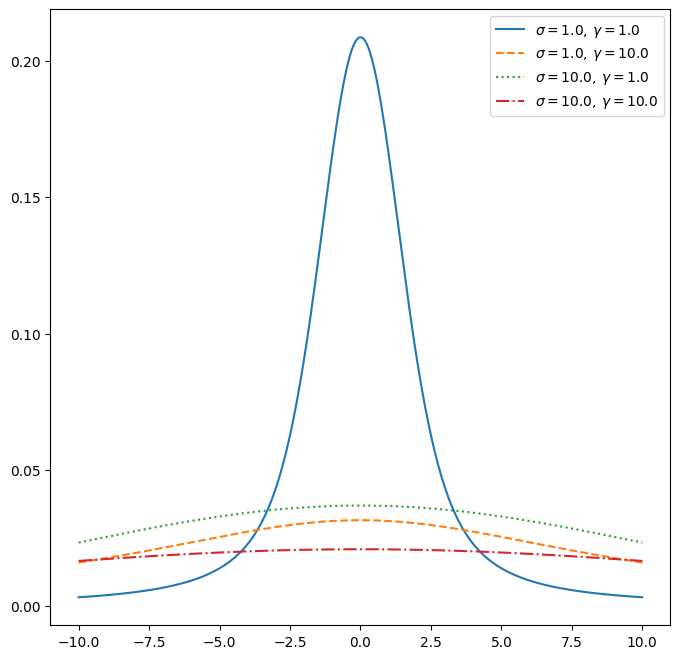

In [ ]:
from scipy.special import voigt_profile
import numpy as np
import matplotlib.pyplot as plt
voigt_profile(2, 1., 1.)

fig, ax = plt.subplots(figsize=(8, 8))
x = np.linspace(-10, 10, 500)
parameters_list = [(1., 1., "solid"), (1., 10., "dashed"),
                   (10., 1., "dotted"), (10., 10., "dashdot")]
for params in parameters_list:
    sigma, gamma, linestyle = params
    voigt = voigt_profile(x, sigma, gamma)
    ax.plot(x, voigt, label=rf"$\sigma={sigma},\, \gamma={gamma}$",
            ls=linestyle)
ax.legend()
plt.show()